In [63]:
!pip install -q --upgrade pip

!pip install -q openai-whisper torch torchvision torchaudio
!pip install -q pyttsx3 soundfile librosa matplotlib numpy
!pip install -q noisereduce gtts sounddevice pydub
!pip install -q imageio-ffmpeg

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [65]:
import os
import torch
import whisper
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import noisereduce as nr
import sounddevice as sd
from gtts import gTTS
from pydub import AudioSegment
import imageio_ffmpeg

os.environ["PATH"] += os.pathsep + os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

In [67]:
nlp_audio_text = """
Today we will learn about Natural Language Processing.

One of the most powerful models in NLP is the Transformer architecture.

Transformers use self-attention to understand relationships between words in a sentence.

This helps models like ChatGPT understand context, long-range dependencies, and generate human-like responses.

Transformers replaced older models like RNNs and LSTMs because they are faster and more accurate on large datasets.

They are used in translation, chatbots, summarization, and speech recognition systems.
"""

tts = gTTS(nlp_audio_text)
audio_file = "nlp_audio.mp3"
tts.save(audio_file)

print("Audio generated successfully:", audio_file)

Audio generated successfully: nlp_audio.mp3


In [68]:
audio = AudioSegment.from_mp3("nlp_audio.mp3")
audio.export("nlp_audio.wav", format="wav")

y, sr = librosa.load("nlp_audio.wav")
sd.play(y, sr)
sd.wait()

In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = whisper.load_model("base")
model = model.to(device)

print("Model running on:", device)

Model running on: cpu


In [79]:
import os
print(os.listdir())

['clean.wav', 'nlp_audio.mp3', 'nlp_audio.wav', 'speech_reasoning_pipeline.ipynb']


In [80]:
from pydub import AudioSegment

audio = AudioSegment.from_mp3("nlp_audio.mp3")
audio.export("clean_nlp.wav", format="wav")

print("WAV recreated successfully")

WAV recreated successfully


In [81]:
result = model.transcribe("clean_nlp.wav", fp16=False)

print(result["text"])

 Today we will learn about natural language processing. One of the most powerful models in NLP is the transformer architecture. Transformers use self-attention to understand relationships between words and a sentence. This helps models like chat GPT understand context, long-range dependencies, and generate human-like responses. Transformers replace older models like RNNs and LSDMs because they are faster and more accurate on. Large data sets. They are used in translation, chatbots, summarization, and speech recognition systems.


In [82]:
for seg in result["segments"]:
    print(f"[{seg['start']:.2f} - {seg['end']:.2f}] {seg['text']}")

[0.00 - 3.76]  Today we will learn about natural language processing.
[3.76 - 9.44]  One of the most powerful models in NLP is the transformer architecture.
[9.44 - 16.08]  Transformers use self-attention to understand relationships between words and a sentence.
[16.08 - 22.48]  This helps models like chat GPT understand context, long-range dependencies,
[22.48 - 25.44]  and generate human-like responses.
[25.44 - 33.20]  Transformers replace older models like RNNs and LSDMs because they are faster and more accurate on.
[33.20 - 42.48]  Large data sets. They are used in translation, chatbots, summarization, and speech recognition systems.


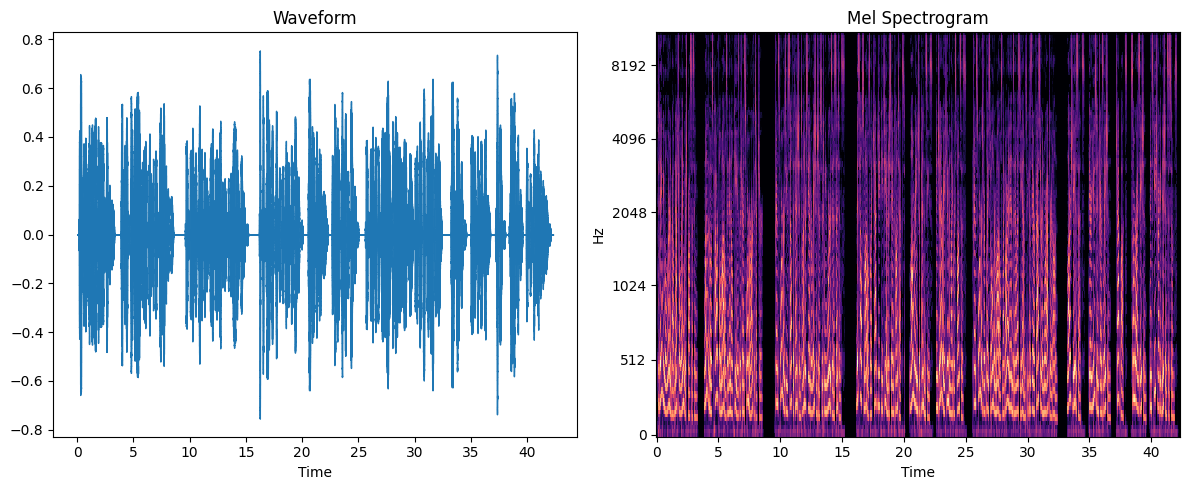

In [83]:
y, sr = librosa.load("clean_nlp.wav")

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")

plt.subplot(1,2,2)
S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel")
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

In [84]:
!pip install -q jiwer

In [86]:
from jiwer import wer, cer

# This is your ORIGINAL script (ground truth text used to generate audio)
reference_text = nlp_audio_text.lower()

# This is Whisper output
predicted_text = result["text"].lower()

# Word Error Rate
wer_score = wer(reference_text, predicted_text)

# Character Error Rate (optional)
cer_score = cer(reference_text, predicted_text)

print("WER (lower is better):", wer_score)
print("CER (lower is better):", cer_score)

# Accuracy (simple form)
accuracy = (1 - wer_score) * 100
print("Approx Accuracy %:", accuracy)

WER (lower is better): 0.1095890410958904
CER (lower is better): 0.031835205992509365
Approx Accuracy %: 89.04109589041096
